# You have before and after. Analyse it as before and after.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/paired-power/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/paired-power/demo.ipynb)

Twelve stores, weekly sales before and after a process change. Someone puts "before" in one column,
"after" in another, and runs a two-sample t-test. That test counts every store's own level as noise.
This notebook measures, exactly, how much power that throws away at each level of pairing - and the
one corner where pairing costs you instead.

1. Calibration - the quadrature against Student's noncentral t, scipy, and raw Monte Carlo
2. Size: the wrong analysis is conservative at rho > 0 and anti-conservative at rho < 0
3. Power of the two analyses of the same data
4. Pairs needed for 80% power - the sample the wrong analysis wastes
5. Negative result: the break-even rho below which pairing costs power
6. One report, read properly
7. Try your own

## The engine

Extracted from `paired.py` at build time, character for character. The paired test is a noncentral t.
The two-sample test on paired data is not: its denominator mixes two correlated variances. Under
normality, (n-1)(s_b^2 + s_a^2) = (1+rho)A + (1-rho)B with A, B independent chi-square(n-1), and the
mean difference is independent of both - so a 2-D Gauss-Legendre quadrature over A and B is exact.

In [1]:
from __future__ import annotations

from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize, stats

ALPHA = 0.05


DELTA = 0.5  # the effect in SD units of one measurement: a "medium" before/after shift


RHOS = (-0.5, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95)


NS = (5, 10, 20, 40, 80)


GL_NODES = 160


MC_REPS = 20000


Z99 = 2.5758


_U, _W = np.polynomial.legendre.leggauss(GL_NODES)


_U, _W = (_U + 1) / 2, _W / 2  # nodes and weights on (0, 1)


def wilson(k: int, n: int, z: float = Z99) -> tuple:
    p = k / n
    c = (p + z * z / (2 * n)) / (1 + z * z / n)
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return max(0.0, c - h), min(1.0, c + h)


def sd_diff(rho: float) -> float:
    """SD of after - before when each has SD 1."""
    return float(np.sqrt(2 * (1 - rho)))


def power_paired(n: int, rho: float, delta: float = DELTA, alpha: float = ALPHA) -> float:
    """Exact two-sided power of the paired t-test: noncentral t with df n-1."""
    df = n - 1
    nc = delta * np.sqrt(n) / sd_diff(rho)
    c = stats.t.ppf(1 - alpha / 2, df)
    # lower tail via symmetry: scipy returns nan for nct.cdf(-c) far out in the tail (nc ~ 10)
    return float(stats.nct.sf(c, df, nc) + stats.nct.sf(c, df, -nc))


def power_independent(n: int, rho: float, delta: float = DELTA, alpha: float = ALPHA) -> float:
    """Exact two-sided rejection rate of Student's two-sample t run on PAIRED data (quadrature)."""
    df = 2 * n - 2
    c = stats.t.ppf(1 - alpha / 2, df)
    a = stats.chi2.ppf(_U, n - 1)[:, None]
    b = stats.chi2.ppf(_U, n - 1)[None, :]
    s2sum = ((1 + rho) * a + (1 - rho) * b) / (n - 1)  # s_b^2 + s_a^2
    k = c * np.sqrt(s2sum / n)  # critical |mean(D)|
    s = sd_diff(rho) / np.sqrt(n)  # true SD of mean(D)
    p = stats.norm.sf((k - delta) / s) + stats.norm.cdf((-k - delta) / s)
    return float(_W @ p @ _W)


def n_for_power(target: float, rho: float, analysis: str, delta: float = DELTA) -> int:
    """Smallest n (pairs) giving at least `target` power. Power rises in n, so bisection is valid."""
    f = power_paired if analysis == "paired" else power_independent
    lo, hi = 2, 4
    while f(hi, rho, delta) < target:
        lo, hi = hi, hi * 2
    while hi - lo > 1:
        mid = (lo + hi) // 2
        lo, hi = (lo, mid) if f(mid, rho, delta) >= target else (mid, hi)
    return hi


def break_even_rho(n: int, delta: float = DELTA) -> float:
    """The rho at which pairing stops costing power: below it the paired test's lost df win."""
    g = lambda r: power_paired(n, r, delta) - power_independent(n, r, delta)  # noqa: E731
    return float(optimize.brentq(g, -0.3, 0.6, xtol=1e-6))


def analyse(before: Sequence[float], after: Sequence[float]) -> Dict:
    """Both analyses on one before/after dataset, plus what the correlation bought."""
    b, a = np.asarray(before, float), np.asarray(after, float)
    if len(b) != len(a):
        raise ValueError(f"before has {len(b)} values and after has {len(a)}: pairs must match")
    if len(b) < 3:
        raise ValueError("need at least 3 pairs")
    d = a - b
    if np.std(d) == 0 or np.std(b) == 0 or np.std(a) == 0:
        raise ValueError("a column (or every difference) is constant, so no test is defined")
    r = float(np.corrcoef(b, a)[0, 1])
    p_pair = float(stats.ttest_rel(a, b).pvalue)
    p_ind = float(stats.ttest_ind(a, b).pvalue)
    return {"n": len(b), "delta": float(d.mean()), "rho_hat": r, "p_paired": p_pair,
            "p_independent": p_ind, "variance_ratio": 1 / (1 - r) if r < 1 else float("inf")}


def grid() -> List[Dict]:
    rows = []
    for n in NS:
        for rho in RHOS:
            rows.append({"n": n, "rho": rho,
                         "size_paired": ALPHA, "size_independent": power_independent(n, rho, 0.0),
                         "power_paired": power_paired(n, rho), "power_independent": power_independent(n, rho)})
    return rows


def calibrate() -> Dict:
    """Three independent checks of the quadrature and of the vectorised statistics."""
    gaps = []
    for n in (3, 5, 10, 40, 200):
        for d in (0.0, 0.3, 0.8):
            df, c = 2 * n - 2, stats.t.ppf(1 - ALPHA / 2, 2 * n - 2)
            nc = d * np.sqrt(n) / np.sqrt(2)
            exact = stats.nct.sf(c, df, nc) + stats.nct.sf(c, df, -nc)
            gaps.append(abs(power_independent(n, 0.0, d) - exact))
    rng = np.random.default_rng(7)
    mism = 0
    for _ in range(400):
        n, rho = int(rng.integers(3, 60)), float(rng.uniform(-0.9, 0.95))
        x = _pairs(rng, n, rho, 0.4, 1)[0]
        b, a = x[:, 0], x[:, 1]
        mism += (_t_paired(b[None], a[None])[0] > 0) != (stats.ttest_rel(a, b).pvalue < ALPHA)
        mism += (_t_indep(b[None], a[None])[0] > 0) != (stats.ttest_ind(a, b).pvalue < ALPHA)
    nodes = abs(power_independent(20, 0.8) - _power_independent_nodes(20, 0.8, 320))
    return {"max_gap_vs_student_nct_at_rho0": float(max(gaps)), "scipy_decision_mismatches": int(mism),
            "decisions_compared": 800, "gap_160_vs_320_nodes": float(nodes)}


def _power_independent_nodes(n: int, rho: float, m: int, delta: float = DELTA) -> float:
    global _U, _W
    keep = _U, _W
    u, w = np.polynomial.legendre.leggauss(m)
    _U, _W = (u + 1) / 2, w / 2
    try:
        return power_independent(n, rho, delta)
    finally:
        _U, _W = keep


def _pairs(rng: np.random.Generator, n: int, rho: float, delta: float, reps: int) -> np.ndarray:
    z1 = rng.standard_normal((reps, n))
    z2 = rho * z1 + np.sqrt(1 - rho * rho) * rng.standard_normal((reps, n))
    return np.stack([z1, z2 + delta], axis=-1)


def _t_paired(b: np.ndarray, a: np.ndarray) -> np.ndarray:
    """Signed margin past the critical value (positive = reject), one row per replicate."""
    n = b.shape[1]
    d = a - b
    t = d.mean(1) / (d.std(1, ddof=1) / np.sqrt(n))
    return np.abs(t) - stats.t.ppf(1 - ALPHA / 2, n - 1)


def _t_indep(b: np.ndarray, a: np.ndarray) -> np.ndarray:
    n = b.shape[1]
    t = (a.mean(1) - b.mean(1)) / np.sqrt((a.var(1, ddof=1) + b.var(1, ddof=1)) / n)
    return np.abs(t) - stats.t.ppf(1 - ALPHA / 2, 2 * n - 2)


MC_DESIGNS = ((10, -0.5, 0.0), (10, 0.0, 0.5), (20, 0.5, 0.0), (20, 0.8, 0.5), (5, 0.9, 0.5), (40, 0.95, 0.5))


def monte_carlo(reps: int = MC_REPS, seed: int = 184) -> List[Dict]:
    """Raw bivariate-normal replicates; each exact rate must sit inside the 99% Wilson interval."""
    rng = np.random.default_rng(seed)
    out = []
    for n, rho, d in MC_DESIGNS:
        x = _pairs(rng, n, rho, d, reps)
        b, a = x[..., 0], x[..., 1]
        row = {"n": n, "rho": rho, "delta": d}
        for name, fn, exact in (("paired", _t_paired, power_paired(n, rho, d)),
                                ("independent", _t_indep, power_independent(n, rho, d))):
            k = int((fn(b, a) > 0).sum())
            lo, hi = wilson(k, reps)
            row[name] = {"exact": exact, "mc": k / reps, "inside_99": bool(lo <= exact <= hi)}
            if not row[name]["inside_99"]:
                # 12 checks at 99% miss once about 11% of the time by chance. A miss is re-run at
                # 10x the reps on a fresh seed and BOTH results are reported, never just the second.
                x2 = _pairs(np.random.default_rng(seed + 1000), n, rho, d, reps * 10)
                k2 = int((fn(x2[..., 0], x2[..., 1]) > 0).sum())
                lo2, hi2 = wilson(k2, reps * 10)
                row[name]["recheck"] = {"reps": reps * 10, "mc": k2 / (reps * 10),
                                        "inside_99": bool(lo2 <= exact <= hi2)}
        out.append(row)
    return out


def exemplar(seed: int = 0) -> Dict:
    """12 stores, weekly sales before/after a process change. Sales SD $4k, stores correlate 0.85
    week to week, the true lift is $2k (0.5 SD). The first seed where the two analyses disagree is
    shown, and the probability of that disagreement is reported next to it, so it is not a
    cherry-pick presented as typical."""
    n, rho, sd, lift = 12, 0.85, 4.0, 2.0
    for s in range(seed, seed + 500):
        rng = np.random.default_rng(s)
        z = _pairs(rng, n, rho, lift / sd, 1)[0]
        before = np.round(30 + sd * z[:, 0], 1)
        after = np.round(30 + sd * z[:, 1], 1)
        res = analyse(before, after)
        if res["p_paired"] < ALPHA <= res["p_independent"]:
            break
    return {"seed": s, "n": n, "rho": rho, "sd": sd, "true_lift": lift,
            "before": before.tolist(), "after": after.tolist(), **res,
            **_disagreement(n, rho, lift / sd)}


def _disagreement(n: int, rho: float, delta: float, reps: int = MC_REPS) -> Dict:
    """How often, on one dataset, each analysis rejects and the other does not (Monte Carlo:
    the joint event has no closed form)."""
    x = _pairs(np.random.default_rng(1840), n, rho, delta, reps)
    rp, ri = _t_paired(x[..., 0], x[..., 1]) > 0, _t_indep(x[..., 0], x[..., 1]) > 0
    return {"p_only_paired": float((rp & ~ri).mean()), "p_only_independent": float((ri & ~rp).mean())}

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every study number here is exact and matches `evidence.txt` to the
digit. Only the raw-data Monte Carlo cross-check runs at 4,000 replicates instead of the study's
20,000, so its intervals are about 2.2x wider - lower resolution, not disagreement. `evidence.txt` is
the reference. A design that misses its 99% interval is re-run at 10x the reps on a fresh seed, and
both results are printed.

## 1. Calibration

In [2]:
print(calibrate())
for r in monte_carlo(4000):
    for k in ("paired", "independent"):
        x = r[k]
        extra = f"  recheck {x['recheck']['mc']:.4f}" if "recheck" in x else ""
        print(f"n={r['n']:>2} rho={r['rho']:>5} delta={r['delta']:.1f} {k:>11}: exact {x['exact']:.4f} "
              f"MC {x['mc']:.4f} {'inside' if x['inside_99'] else 'OUTSIDE'}{extra}")

{'max_gap_vs_student_nct_at_rho0': 3.46395563899371e-07, 'scipy_decision_mismatches': 0, 'decisions_compared': 800, 'gap_160_vs_320_nodes': 1.5118205545783248e-07}
n=10 rho= -0.5 delta=0.0      paired: exact 0.0500 MC 0.0535 inside
n=10 rho= -0.5 delta=0.0 independent: exact 0.1072 MC 0.1082 inside
n=10 rho=  0.0 delta=0.5      paired: exact 0.1706 MC 0.1668 inside
n=10 rho=  0.0 delta=0.5 independent: exact 0.1851 MC 0.1797 inside
n=20 rho=  0.5 delta=0.0      paired: exact 0.0500 MC 0.0475 inside
n=20 rho=  0.5 delta=0.0 independent: exact 0.0075 MC 0.0080 inside
n=20 rho=  0.8 delta=0.5      paired: exact 0.9180 MC 0.9147 inside
n=20 rho=  0.8 delta=0.5 independent: exact 0.2161 MC 0.2190 inside
n= 5 rho=  0.9 delta=0.5      paired: exact 0.4773 MC 0.4662 inside
n= 5 rho=  0.9 delta=0.5 independent: exact 0.0283 MC 0.0295 inside
n=40 rho= 0.95 delta=0.5      paired: exact 1.0000 MC 1.0000 inside
n=40 rho= 0.95 delta=0.5 independent: exact 0.7951 MC 0.7923 inside


At rho = 0 the quadrature agrees with Student's noncentral t to about 3e-7, doubling the nodes moves
it by about 1e-7, and the vectorised tests make the same decision as `scipy.stats.ttest_rel` /
`ttest_ind` on 800 of 800 random datasets.

In the full 20,000-rep study one of 12 checks missed (n = 40, rho = 0.95, exact 0.7951, MC 0.8025).
Twelve checks at 99% miss once about 11% of the time by chance; re-run at 200,000 reps it lands at
0.7949. Both runs are in `evidence.txt`.

## 2. Size - how often each analysis rejects a TRUE null

The paired test is exact at 0.05 for every rho. The two-sample test on the same data is not.

In [3]:
rows = grid()
def cell(n, rho):
    return next(r for r in rows if r["n"] == n and r["rho"] == rho)
print(" n pairs" + "".join(f"{r:>8}" for r in RHOS))
for n in NS:
    print(f"{n:>7} " + "".join(f"{cell(n, r)['size_independent']:>8.4f}" for r in RHOS))

 n pairs    -0.5    -0.2     0.0     0.2     0.4     0.6     0.8     0.9    0.95
      5   0.1035  0.0693  0.0500  0.0334  0.0197  0.0092  0.0024  0.0006  0.0002
     10   0.1072  0.0717  0.0500  0.0308  0.0154  0.0050  0.0005  0.0000  0.0000
     20   0.1085  0.0727  0.0500  0.0296  0.0134  0.0033  0.0001  0.0000  0.0000
     40   0.1091  0.0731  0.0500  0.0290  0.0124  0.0026  0.0000  0.0000  0.0000
     80   0.1093  0.0734  0.0500  0.0287  0.0119  0.0023  0.0000  0.0000  0.0000


At rho > 0 the two-sample test is conservative: 0.0033 at rho = 0.6, n = 20. It looks "safe", and that
is exactly why it survives review. At rho < 0 - a see-saw, a budget moved from one line to another -
it is **anti-conservative**: 0.109 at rho = -0.5, more than double its label.

## 3. Power at a true shift of 0.5 SD - paired / two-sample, same data

In [4]:
print(" n pairs" + "".join(f"{'rho=' + str(r):>14}" for r in RHOS))
for n in NS:
    print(f"{n:>7} " + "".join(f"{cell(n, r)['power_paired']:>6.3f}/{cell(n, r)['power_independent']:<7.3f}" for r in RHOS))

 n pairs      rho=-0.5      rho=-0.2       rho=0.0       rho=0.2       rho=0.4       rho=0.6       rho=0.8       rho=0.9      rho=0.95
      5  0.080/0.162   0.087/0.128   0.095/0.108   0.106/0.088   0.125/0.070   0.163/0.052   0.276/0.036   0.477/0.028   0.753/0.025  
     10  0.130/0.237   0.150/0.207   0.171/0.185   0.201/0.161   0.253/0.134   0.352/0.103   0.606/0.065   0.881/0.043   0.993/0.032  
     20  0.232/0.369   0.278/0.351   0.324/0.338   0.389/0.321   0.491/0.300   0.660/0.268   0.918/0.216   0.997/0.172   1.000/0.140  
     40  0.429/0.581   0.512/0.590   0.587/0.598   0.684/0.609   0.804/0.625   0.932/0.650   0.998/0.699   1.000/0.750   1.000/0.795  
     80  0.723/0.833   0.814/0.860   0.878/0.882   0.937/0.907   0.981/0.936   0.999/0.968   1.000/0.994   1.000/1.000   1.000/1.000  


At n = 20 and rho = 0.8 the paired test finds the shift 92% of the time; the two-sample test on the
same numbers finds it 22% of the time. And as the pairing tightens the two-sample test gets WORSE at
small n (0.108 -> 0.025 at n = 5): its false-positive rate falls toward zero and takes its power with it.

## 4. Pairs needed for 80% power

In [5]:
for rho in (0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.95):
    a, b = n_for_power(0.8, rho, "paired"), n_for_power(0.8, rho, "independent")
    print(f"rho = {rho}   paired {a:>3}   two-sample {b:>3}   wasted {b - a:>3} pairs ({b / a:.1f}x)")

rho = 0.0   paired  65   two-sample  64   wasted  -1 pairs (1.0x)
rho = 0.2   paired  53   two-sample  60   wasted   7 pairs (1.1x)
rho = 0.4   paired  40   two-sample  56   wasted  16 pairs (1.4x)
rho = 0.5   paired  34   two-sample  54   wasted  20 pairs (1.6x)
rho = 0.6   paired  28   two-sample  52   wasted  24 pairs (1.9x)
rho = 0.8   paired  15   two-sample  46   wasted  31 pairs (3.1x)
rho = 0.9   paired   9   two-sample  43   wasted  34 pairs (4.8x)
rho = 0.95   paired   6   two-sample  41   wasted  35 pairs (6.8x)


At rho = 0.9 the paired analysis needs 9 pairs and the wrong analysis 43. The two-sample test cannot
go below about 31 pairs whatever rho is, because it prices the mean difference at variance 2/n; the
paired test prices it at its true 2(1-rho)/n.

## 5. Negative result - pairing is not free

The paired test uses n-1 degrees of freedom instead of 2n-2. If the pairing is weak, that loss is
bigger than what the correlation buys back.

n =   3 pairs   break-even rho = 0.107
n =   5 pairs   break-even rho = 0.086
n =  10 pairs   break-even rho = 0.059
n =  20 pairs   break-even rho = 0.040
n =  40 pairs   break-even rho = 0.028
n =  80 pairs   break-even rho = 0.020


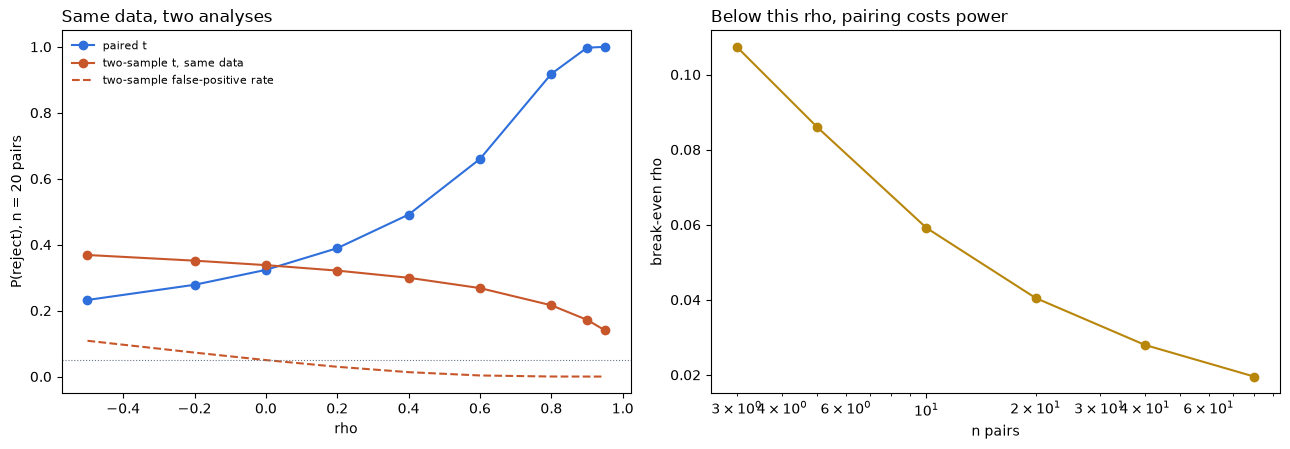

In [6]:
for n in (3, 5, 10, 20, 40, 80):
    print(f"n = {n:>3} pairs   break-even rho = {break_even_rho(n):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
rs = list(RHOS)
axes[0].plot(rs, [cell(20, r)["power_paired"] for r in rs], "o-", color="#2f6fdb", label="paired t")
axes[0].plot(rs, [cell(20, r)["power_independent"] for r in rs], "o-", color="#c8562b", label="two-sample t, same data")
axes[0].plot(rs, [cell(20, r)["size_independent"] for r in rs], "--", color="#c8562b", label="two-sample false-positive rate")
axes[0].axhline(ALPHA, color="#6b7684", lw=0.8, ls=":")
axes[0].set_xlabel("rho"); axes[0].set_ylabel("P(reject), n = 20 pairs"); axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title("Same data, two analyses", loc="left")
ns_ = [3, 5, 10, 20, 40, 80]
axes[1].plot(ns_, [break_even_rho(n) for n in ns_], "o-", color="#b8860b")
axes[1].set_xscale("log"); axes[1].set_xlabel("n pairs"); axes[1].set_ylabel("break-even rho")
axes[1].set_title("Below this rho, pairing costs power", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

The break-even is small: 0.107 at 3 pairs, 0.020 at 80. The cost below it is small too (at n = 5,
rho = 0: 0.095 vs 0.108). So this is not a reason to ignore pairing - measurements on the same unit
almost always correlate far above 0.1 - but it is why "always pair" is not a free lunch on tiny samples
with a weak link. And the choice must be made from the design, not from which p-value came out smaller.

## 6. One report, read properly

In [7]:
ex = exemplar()
print(f"seed {ex['seed']}: 12 stores, SD $4k, rho 0.85, true lift $2k")
print(f"observed lift ${ex['delta']:.2f}k, sample rho {ex['rho_hat']:.3f}")
print(f"paired t p = {ex['p_paired']:.4f}    two-sample t p = {ex['p_independent']:.4f}")
print(f"at this design only the paired test rejects {ex['p_only_paired']:.1%} of the time; "
      f"only the two-sample test {ex['p_only_independent']:.3%}")

seed 0: 12 stores, SD $4k, rho 0.85, true lift $2k
observed lift $1.46k, sample rho 0.745
paired t p = 0.0410    two-sample t p = 0.2538
at this design only the paired test rejects 74.6% of the time; only the two-sample test 0.005%


The same twelve pairs are a finding (p = 0.041) or "no significant difference" (p = 0.254) depending on
whether the analysis remembers that each row is one store. At this design that disagreement is not a
fluke: it happens on 75% of datasets.

## Summary

| claim | what the numbers say |
|---|---|
| "two-sample t on paired data is just conservative" | at rho = 0.8, n = 20 it keeps 22% power of the paired test's 92% |
| "it is at least safe" | not at rho < 0: false-positive rate 0.109 at rho = -0.5 |
| "pairing is free" | no: below rho ~0.02-0.11 (depending on n) it costs a little power |
| the sample the wrong analysis wastes | 34 of 43 pairs at rho = 0.9 |

## 7. Try your own

In [8]:
# before = [12.1, 14.3, 9.8, 11.0, 13.5, 10.2, 12.8, 11.9]
# after  = [12.9, 15.0, 10.1, 11.8, 14.6, 10.4, 13.9, 12.3]
# r = analyse(before, after)
# print(round(r["rho_hat"], 3), round(r["p_paired"], 4), round(r["p_independent"], 4))
# print("pairs for 80% power at rho 0.7:", n_for_power(0.8, 0.7, "paired"), "vs", n_for_power(0.8, 0.7, "independent"))
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/paired-power)

Streamlit version, where you paste your own before and after:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`t-test-variants`](../t-test-variants) measured the five t-tests' error rates;
[`ci-overlap-fallacy`](../ci-overlap-fallacy) showed that on paired data overlapping bars hide
significant results; [`cuped-variance`](../cuped-variance) buys the same variance reduction from a
pre-period covariate in an A/B test.